In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_PATH = '/content/drive/MyDrive/ML final project'

if not os.path.exists(PROJECT_PATH):
    os.makedirs(PROJECT_PATH)
    print(f"it created: {PROJECT_PATH}")

%cd {PROJECT_PATH}

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/13YZMRWkS2eT6kmRi5e5vzlG7Yl3Vbt3z/ML final project


In [2]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
import mlflow
import mlflow.sklearn

In [4]:
import os
# ვბეჭდავთ მიმდინარე ფოლდერში არსებული ყველა ფაილის სიას
print(os.listdir('.'))

['walmart-recruiting-store-sales-forecasting.zip', 'walmart_data', '.ipynb_checkpoints', '__pycache__', 'feature_importance.png', 'data_preprocessing.ipynb', 'learning_curve.png', 'xgboost_walmart_submission_mlflow.csv', 'custom_transformers.py', 'submission.csv', 'submission_v2.csv', 'XGBoost.ipynb', 'model_inference_XGBoost.ipynb', 'N-BEATS.ipynb', 'walmart_transformers.py', 'N-BEATS1.ipynb', 'LightGBM']


In [5]:
!pip install dagshub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.6 MB/s eta 0:00:00


In [6]:
import dagshub
dagshub.init(repo_owner='mesata', repo_name='Walmart---Store-Sales-Forecasting', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=c4c6ab29-37e7-4dd2-904c-a3fe00d06b96&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=1884dc8e177ef6895129c2f9016e5a5131afdab1b515020ed2347ad7bb7b6c83




Accessing as mesata

Initialized MLflow to track repo "mesata/Walmart---Store-Sales-Forecasting"

Repository mesata/Walmart---Store-Sales-Forecasting initialized!

## Feature Engineering


In [7]:
%%writefile transformers.py
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class WalmartDataTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, features_df, stores_df):
        self.features_df = features_df.copy()
        self.stores_df = stores_df.copy()
        self.features_df['Date'] = pd.to_datetime(self.features_df['Date'])
        self._type_categories = sorted(self.stores_df['Type'].dropna().unique().tolist())

        self.history_df = None
        self.global_means = {}

    def fit(self, X, y=None):
        """
        Learns historical trends and distributions from the training set
        to safely apply them during transform without leakage.
        """
        df = X.copy()
        if y is not None:
            df['Weekly_Sales'] = y

        df['Date'] = pd.to_datetime(df['Date'])

        if 'Weekly_Sales' in df.columns:
            self.history_df = df[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()

            self.global_means = df.groupby(['Store', 'Dept'])['Weekly_Sales'].mean().to_dict()

        return self

    def transform(self, X):
        """
        Transforms features by pulling lags strictly from the fitted history,
        preventing look-ahead validation oracle leakage.
        """
        df = X.copy()
        df['Date'] = pd.to_datetime(df['Date'])

        df = df.merge(self.stores_df, on='Store', how='left')
        df = df.merge(self.features_df, on=['Store', 'Date'], how='left')

        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month
        df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

        if 'IsHoliday_x' in df.columns:
            df['IsHoliday'] = df['IsHoliday_x'].astype(int)
        elif 'IsHoliday' in df.columns:
            df['IsHoliday'] = df['IsHoliday'].astype(int)

        if 'Type' in df.columns:
            df['Type'] = pd.Categorical(df['Type'], categories=self._type_categories).codes

        if self.history_df is not None:
            df['Date_lag_52'] = df['Date'] - pd.Timedelta(days=364)

            lag_52_df = self.history_df.rename(columns={'Date': 'Date_lag_52', 'Weekly_Sales': 'sales_lag_52'})
            df = df.merge(lag_52_df, on=['Store', 'Dept', 'Date_lag_52'], how='left')
            df.drop(columns=['Date_lag_52'], inplace=True)

            store_dept_keys = list(zip(df['Store'], df['Dept']))
            fallback_vals = [self.global_means.get(key, 0) for key in store_dept_keys]

            df['sales_lag_52'] = df['sales_lag_52'].fillna(pd.Series(fallback_vals, index=df.index))
        else:
            df['sales_lag_52'] = 0

        df = df.sort_values(by=['Store', 'Dept', 'Date']).reset_index(drop=True)

        other_cols = [c for c in df.columns if c not in ['Weekly_Sales', 'sales_lag_52']]
        df[other_cols] = df[other_cols].fillna(0)

        return df


class TimeSeriesSplitter:
    def __init__(self, split_date='2012-01-01', target_col='Weekly_Sales', date_col='Date'):
        self.split_date = pd.to_datetime(split_date)
        self.target_col = target_col
        self.date_col = date_col

    def split(self, df):
        """
        Splits data chronologically. Notice that feature transformations should be applied
        independently using the fitted transformer states to guarantee zero leakage.
        """
        df = df.copy()
        df[self.date_col] = pd.to_datetime(df[self.date_col])
        df = df.sort_values(by=self.date_col).reset_index(drop=True)

        train_mask = df[self.date_col] < self.split_date
        val_mask = df

Writing transformers.py


In [8]:
from transformers import WalmartDataTransformer, TimeSeriesSplitter

In [9]:
import importlib
import transformers

importlib.reload(transformers)
from transformers import WalmartDataTransformer, TimeSeriesSplitter

In [19]:
%%writefile transformers.py
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class WalmartDataTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, features_df, stores_df):
        self.features_df = features_df.copy()
        self.stores_df = stores_df.copy()
        self.features_df['Date'] = pd.to_datetime(self.features_df['Date'])
        self._type_categories = sorted(self.stores_df['Type'].dropna().unique().tolist())

        self.history_df = None
        self.global_means = {}

    def fit(self, X, y=None):
        df = X.copy()
        if y is not None:
            df['Weekly_Sales'] = y

        df['Date'] = pd.to_datetime(df['Date'])

        if 'Weekly_Sales' in df.columns:
            self.history_df = df[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()
            self.global_means = df.groupby(['Store', 'Dept'])['Weekly_Sales'].mean().to_dict()

        return self

    def transform(self, X):
        df = X.copy()
        df['Date'] = pd.to_datetime(df['Date'])

        df = df.merge(self.stores_df, on='Store', how='left')
        df = df.merge(self.features_df, on=['Store', 'Date'], how='left')

        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month
        df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

        if 'IsHoliday_x' in df.columns:
            df['IsHoliday'] = df['IsHoliday_x'].astype(int)
        elif 'IsHoliday' in df.columns:
            df['IsHoliday'] = df['IsHoliday'].astype(int)

        if 'Type' in df.columns:
            df['Type'] = pd.Categorical(df['Type'], categories=self._type_categories).codes

        if self.history_df is not None:
            df['Date_lag_52'] = df['Date'] - pd.Timedelta(days=364)
            lag_52_df = self.history_df.rename(columns={'Date': 'Date_lag_52', 'Weekly_Sales': 'sales_lag_52'})
            df = df.merge(lag_52_df, on=['Store', 'Dept', 'Date_lag_52'], how='left')
            df.drop(columns=['Date_lag_52'], inplace=True)

            store_dept_keys = list(zip(df['Store'], df['Dept']))
            fallback_vals = [self.global_means.get(key, 0) for key in store_dept_keys]
            df['sales_lag_52'] = df['sales_lag_52'].fillna(pd.Series(fallback_vals, index=df.index))
        else:
            df['sales_lag_52'] = 0

        df = df.sort_values(by=['Store', 'Dept', 'Date']).reset_index(drop=True)

        other_cols = [c for c in df.columns if c not in ['Weekly_Sales', 'sales_lag_52']]
        df[other_cols] = df[other_cols].fillna(0)

        return df


class TimeSeriesSplitter:
    def __init__(self, split_date='2012-01-01', target_col='Weekly_Sales', date_col='Date'):
        self.split_date = pd.to_datetime(split_date)
        self.target_col = target_col
        self.date_col = date_col

    def split(self, df):
        df = df.copy()
        df[self.date_col] = pd.to_datetime(df[self.date_col])
        df = df.sort_values(by=self.date_col).reset_index(drop=True)

        train_mask = df[self.date_col] < self.split_date
        val_mask = df[self.date_col] >= self.split_date

        train_data = df[train_mask].reset_index(drop=True)
        val_data = df[val_mask].reset_index(drop=True)

        y_train = train_data[self.target_col] if self.target_col in train_data.columns else None
        y_val = val_data[self.target_col] if self.target_col in val_data.columns else None

        features_to_drop = [self.target_col, 'IsHoliday_x', 'IsHoliday_y']
        X_train = train_data.drop(columns=features_to_drop, errors='ignore')
        X_val = val_data.drop(columns=features_to_drop, errors='ignore')

        return X_train, y_train, X_val, y_val

Overwriting transformers.py


In [20]:
import importlib
import transformers

importlib.reload(transformers)
from transformers import WalmartDataTransformer, TimeSeriesSplitter

print("Transformers module reloaded successfully.")

Transformers module reloaded successfully.


In [100]:
train_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/train.csv.zip')
features_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/features.csv.zip')
stores_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/stores.csv')

splitter = TimeSeriesSplitter(split_date='2012-01-01')
train_raw_df = train_df[train_df['Date'] < '2012-01-01'].copy()
val_raw_df = train_df[train_df['Date'] >= '2012-01-01'].copy()

transformer = WalmartDataTransformer(features_df=features_df, stores_df=stores_df)
transformer.fit(train_raw_df, y=train_raw_df['Weekly_Sales'])

train_processed = transformer.transform(train_raw_df)
val_processed = transformer.transform(val_raw_df)

X_val_raw = val_processed.copy()

y_train = train_processed['Weekly_Sales']
y_val = val_processed['Weekly_Sales']

features_to_drop = ['Weekly_Sales', 'Date']
X_train = train_processed.drop(columns=features_to_drop, errors='ignore')
X_val = val_processed.drop(columns=features_to_drop, errors='ignore')

print(f"Perfectly aligned Train Matrix: {X_train.shape}, Target: {y_train.shape}")
print(f"Perfectly aligned Validation Matrix: {X_val.shape}, Target: {y_val.shape}")

Perfectly aligned Train Matrix: (294132, 20), Target: (294132,)
Perfectly aligned Validation Matrix: (127438, 20), Target: (127438,)


lag52- xedavs wina wels ra moxda

## Training


In [38]:
import lightgbm as lgb
import mlflow.lightgbm

mlflow.set_experiment("Walmart_LightGBM_Forecasting")
with mlflow.start_run(run_name="baseline_lightGBM"):
    model = lgb.LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    weights = X_val['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values
    absolute_errors = np.abs(y_val - y_pred)
    final_wmae = np.sum(weights * absolute_errors) / np.sum(weights)
    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_val", final_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="model")

2026/07/11 18:04:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run baseline_lightGBM at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/22a16f7c85c34d83a0ac597851d274bf
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


lets visualize results

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_2759/2836495873.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


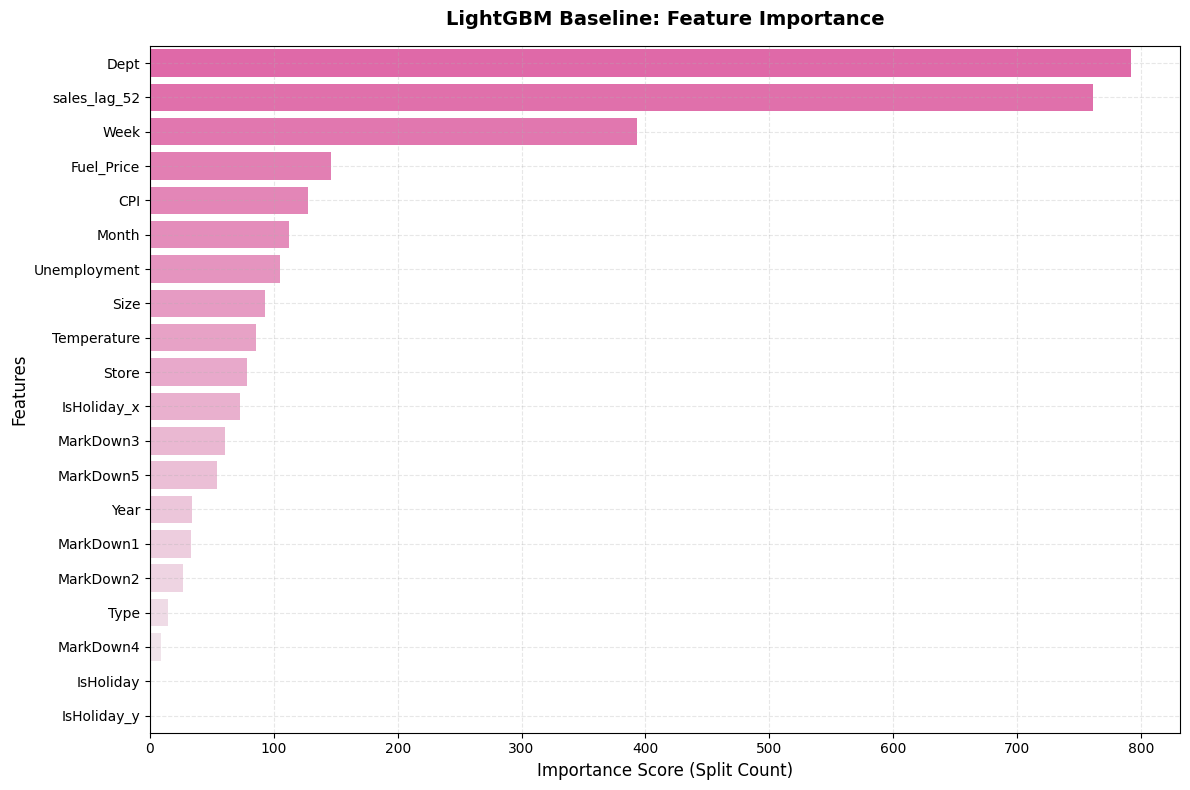

In [40]:
feature_imp = pd.DataFrame(sorted(zip(model.feature_importances_, X_train.columns)), columns=['Value','Feature'])

plt.figure(figsize=(12, 8))
sns.barplot(
    x="Value",
    y="Feature",
    data=feature_imp.sort_values(by="Value", ascending=False),
    palette=sns.color_palette("light:#f256a9_r", n_colors=len(feature_imp))
)
plt.title('LightGBM Baseline: Feature Importance', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Split Count)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

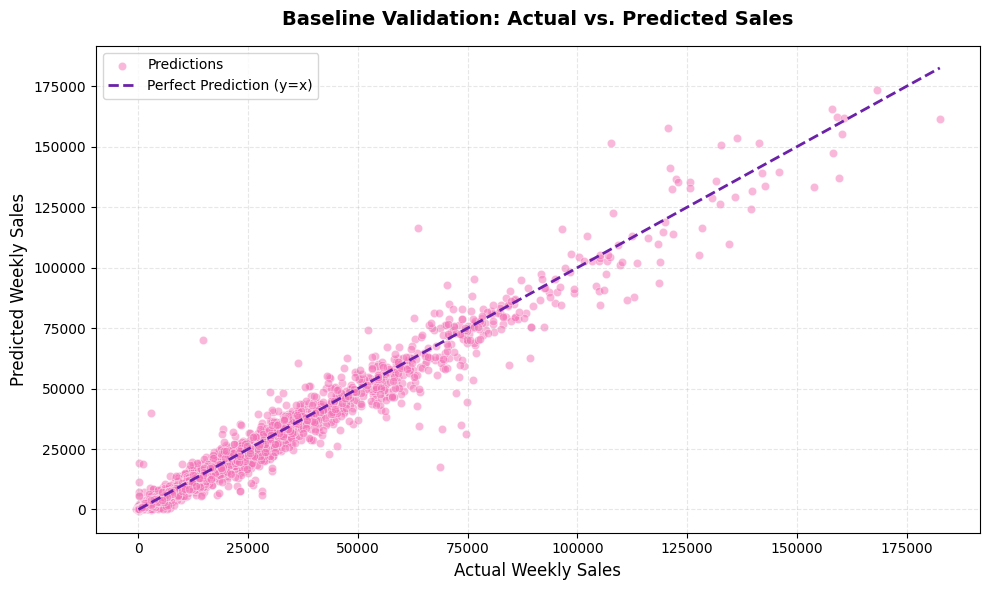

In [41]:
plt.figure(figsize=(10, 6))

indices = np.random.choice(len(y_val), size=5000, replace=False)
val_sample = y_val.iloc[indices] if hasattr(y_val, 'iloc') else y_val[indices]
pred_sample = y_pred[indices]

sns.scatterplot(
    x=val_sample,
    y=pred_sample,
    color='#f472b7',
    alpha=0.5,
    label='Predictions'
)

max_val = max(val_sample.max(), pred_sample.max())
plt.plot([0, max_val], [0, max_val], color='#6b21a8', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

plt.title('Baseline Validation: Actual vs. Predicted Sales', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Weekly Sales', fontsize=12)
plt.ylabel('Predicted Weekly Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

 სტრუქტურა სწორია, მაგრამ პიკებს ვერ წვდება ბოლომდე.

In [42]:
with mlflow.start_run(run_name="LGBM_Objective_MAE"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=500,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
    )

    y_pred = model.predict(X_val)

    weights = X_val['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values
    absolute_errors = np.abs(y_val - y_pred)
    mae_obj_wmae = np.sum(weights * absolute_errors) / np.sum(weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_val", mae_obj_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="model")

2026/07/11 18:05:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run LGBM_Objective_MAE at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/1031378c36fd4c9a8cecaa4a7b7c99e1
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


/tmp/ipykernel_2759/2415104487.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


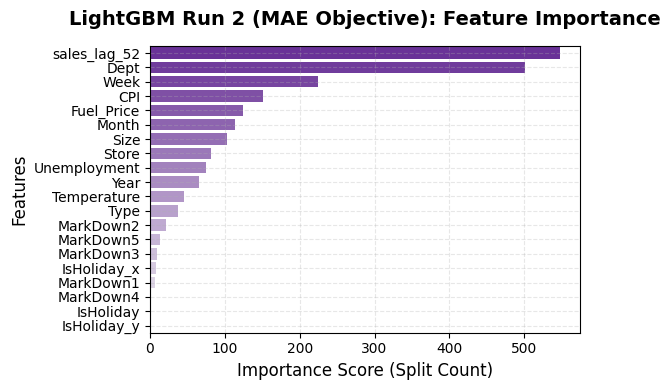

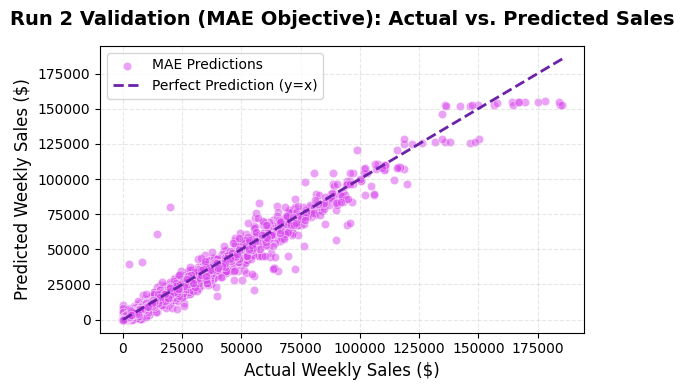

In [43]:
feature_imp = pd.DataFrame(sorted(zip(model.feature_importances_, X_train.columns)), columns=['Value','Feature'])

plt.figure(figsize=(6, 4))
sns.barplot(
    x="Value",
    y="Feature",
    data=feature_imp.sort_values(by="Value", ascending=False),
    palette=sns.color_palette("light:#6b21a8_r", n_colors=len(feature_imp))
)
plt.title('LightGBM Run 2 (MAE Objective): Feature Importance', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Split Count)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))

indices = np.random.choice(len(y_val), size=5000, replace=False)
val_sample = y_val.iloc[indices] if hasattr(y_val, 'iloc') else y_val[indices]
pred_sample = y_pred[indices]

sns.scatterplot(
    x=val_sample,
    y=pred_sample,
    color='#d946ef',
    alpha=0.5,
    label='MAE Predictions'
)

max_val = max(val_sample.max(), pred_sample.max())
plt.plot([0, max_val], [0, max_val], color='#6b21a8', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

plt.title('Run 2 Validation (MAE Objective): Actual vs. Predicted Sales', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Weekly Sales ($)', fontsize=12)
plt.ylabel('Predicted Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()




მეტი ყურადღება ეთმობა წინა წლის გაყიდვებს, მაგრამ პიკებში მაინც ცდება.



In [44]:
with mlflow.start_run(run_name="LGBM_MAE_LR_0.03"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1000,
        learning_rate=0.03,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    y_pred = model.predict(X_val)

    weights = X_val['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values
    absolute_errors = np.abs(y_val - y_pred)
    lr_tuned_wmae = np.sum(weights * absolute_errors) / np.sum(weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_val", lr_tuned_wmae)
    mlflow.lightgbm.log_model(model, name="model")

🏃 View run LGBM_MAE_LR_0.03 at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/17e3b9de72ff4278a36ee64eafb3e0d5
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


In [45]:
print (lr_tuned_wmae)

1807.650671407229


es kargia kargia kargiaaa.

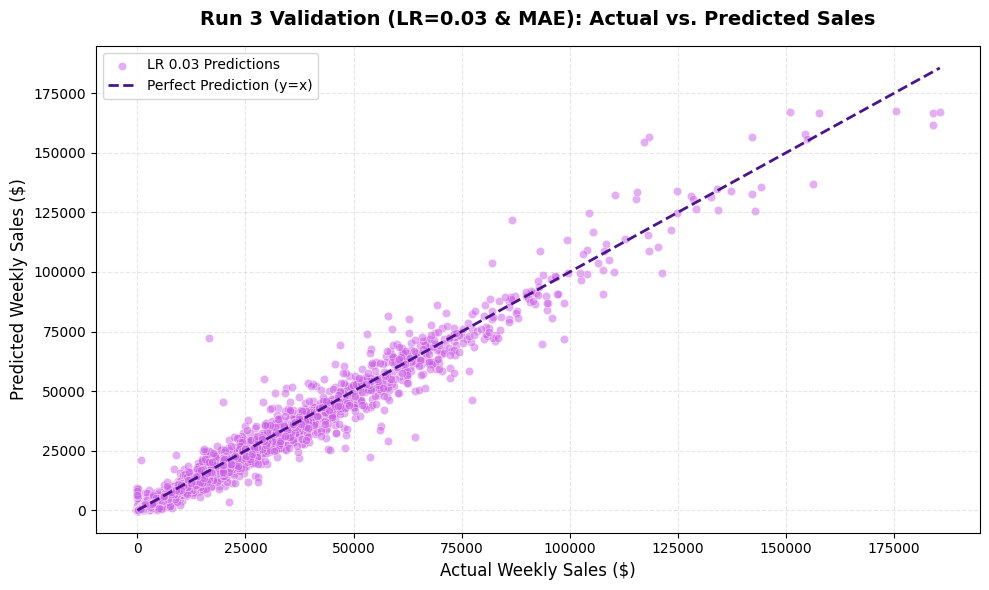

In [46]:
plt.figure(figsize=(10, 6))

indices = np.random.choice(len(y_val), size=5000, replace=False)
val_sample = y_val.iloc[indices] if hasattr(y_val, 'iloc') else y_val[indices]
pred_sample = y_pred[indices]

sns.scatterplot(
    x=val_sample,
    y=pred_sample,
    color='#cc5de8',
    alpha=0.5,
    label='LR 0.03 Predictions'
)

max_val = max(val_sample.max(), pred_sample.max())
plt.plot([0, max_val], [0, max_val], color='#4a148c', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

plt.title('Run 3 Validation (LR=0.03 & MAE): Actual vs. Predicted Sales', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Weekly Sales ($)', fontsize=12)
plt.ylabel('Predicted Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

გავზარდოთ

In [47]:
with mlflow.start_run(run_name="LGBM_MAE_Leaves_63"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    y_pred = model.predict(X_val)

    weights = X_val['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values
    absolute_errors = np.abs(y_val - y_pred)
    leaves_tuned_wmae = np.sum(weights * absolute_errors) / np.sum(weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_val", leaves_tuned_wmae)
    mlflow.lightgbm.log_model(model, name="model")

🏃 View run LGBM_MAE_Leaves_63 at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/fbc250064f6848ce94f7d1721b549505
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


In [48]:
print (leaves_tuned_wmae)

1809.8414796768218


In [49]:

with mlflow.start_run(run_name="LGBM_MAE_Regularized"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    y_pred = model.predict(X_val)

    weights = X_val['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values
    absolute_errors = np.abs(y_val - y_pred)
    reg_tuned_wmae = np.sum(weights * absolute_errors) / np.sum(weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_val", reg_tuned_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="model")

    print(reg_tuned_wmae)

2026/07/11 18:08:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


1766.40876069125
🏃 View run LGBM_MAE_Regularized at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/0295b51c2230467caae6859496b0c616
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


2026/07/11 18:09:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


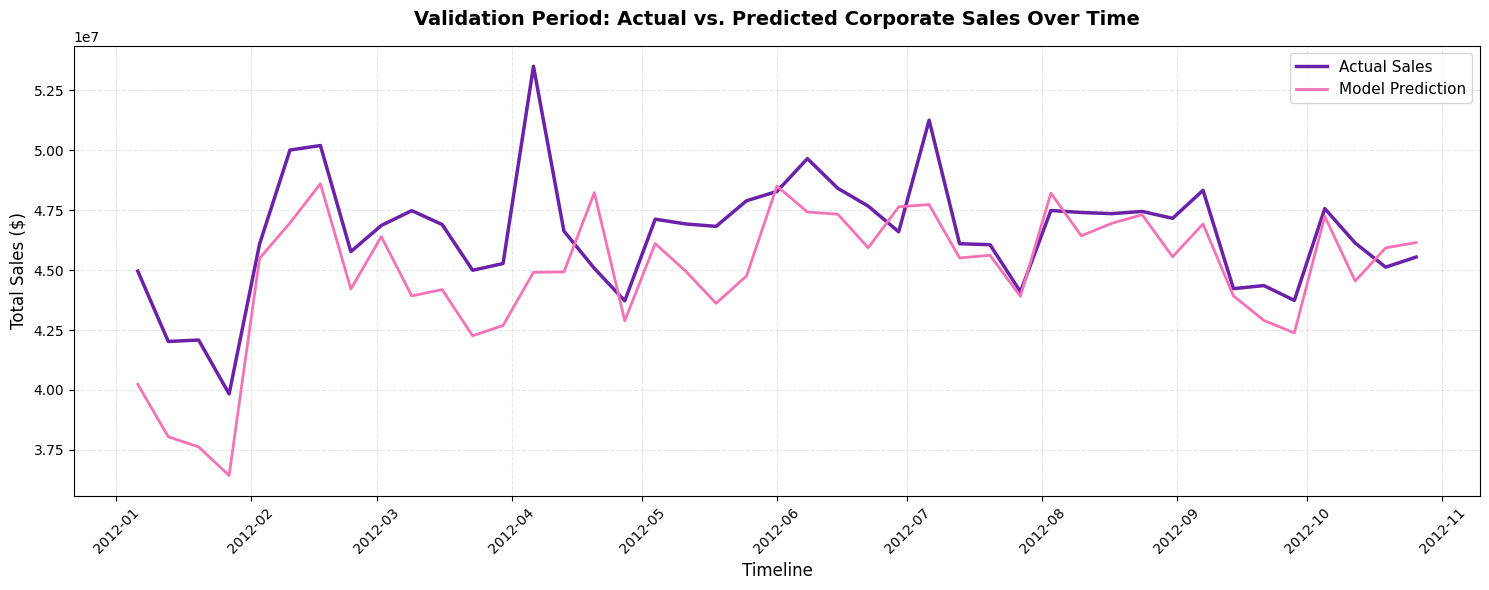

🏃 View run LGBM_MAE_Leaves_63 at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/97cd0c655758404190c089aa24079ea6
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


In [50]:
import os
import matplotlib.pyplot as plt
import lightgbm as lgb
import mlflow.lightgbm

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_MAE_Leaves_63"):
    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    y_pred = model.predict(X_val)

    weights = X_val['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values
    absolute_errors = np.abs(y_val - y_pred)
    leaves_tuned_wmae = np.sum(weights * absolute_errors) / np.sum(weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_val", leaves_tuned_wmae)

    mlflow.lightgbm.log_model(model, artifact_path="model")

    val_timeline = pd.DataFrame({
        'Date': pd.to_datetime(X_val_raw['Date']),
        'Actual': y_val,
        'Predicted': y_pred
    })

    val_timeline = val_timeline.groupby('Date').sum().reset_index()
    val_timeline = val_timeline.sort_values('Date')

    plt.figure(figsize=(15, 6))
    plt.plot(
        val_timeline['Date'],
        val_timeline['Actual'],
        color='#6b21a8',
        linewidth=2.5,
        label='Actual Sales'
    )
    plt.plot(
        val_timeline['Date'],
        val_timeline['Predicted'],
        color='#f472b6',
        linewidth=2,
        label='Model Prediction'
    )

    plt.title('Validation Period: Actual vs. Predicted Corporate Sales Over Time', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Timeline', fontsize=12)
    plt.ylabel('Total Sales ($)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(loc='upper right', fontsize=11)
    plt.xticks(rotation=45)
    plt.tight_layout()

    plot_path = "val_actual_vs_predicted.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path)

    plt.show()

    if os.path.exists(plot_path):
        os.remove(plot_path)

underestimates shvreba sul

In [51]:
def asymmetric_mae_objective(y_true, y_pred):
    residual = y_true - y_pred
    grad = np.where(residual > 0, -1.75, 1.0)
    hess = np.ones_like(y_true)
    return grad, hess

with mlflow.start_run(run_name="LGBM_Asymmetric_MAE"):

    model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.set_params(objective=asymmetric_mae_objective)

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    y_pred = model.predict(X_val)

    weights = X_val['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values
    absolute_errors = np.abs(y_val - y_pred)
    asym_wmae = np.sum(weights * absolute_errors) / np.sum(weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_val", asym_wmae)

    mlflow.lightgbm.log_model(
        model,
        artifact_path="model",
        skops_trusted_types=["__main__.asymmetric_mae_objective"]
    )

    print(asym_wmae)

2026/07/11 18:10:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 18:10:50 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpfo8utfu6/model, flavor: lightgbm). Fall back to return ['lightgbm==4.6.0', 'skops==0.14.0']. Set logging level to DEBUG to see the full traceback. 


15770.171036696454
🏃 View run LGBM_Asymmetric_MAE at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/291711fe1f944956bd2217040e09ee59
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


ES RAARI

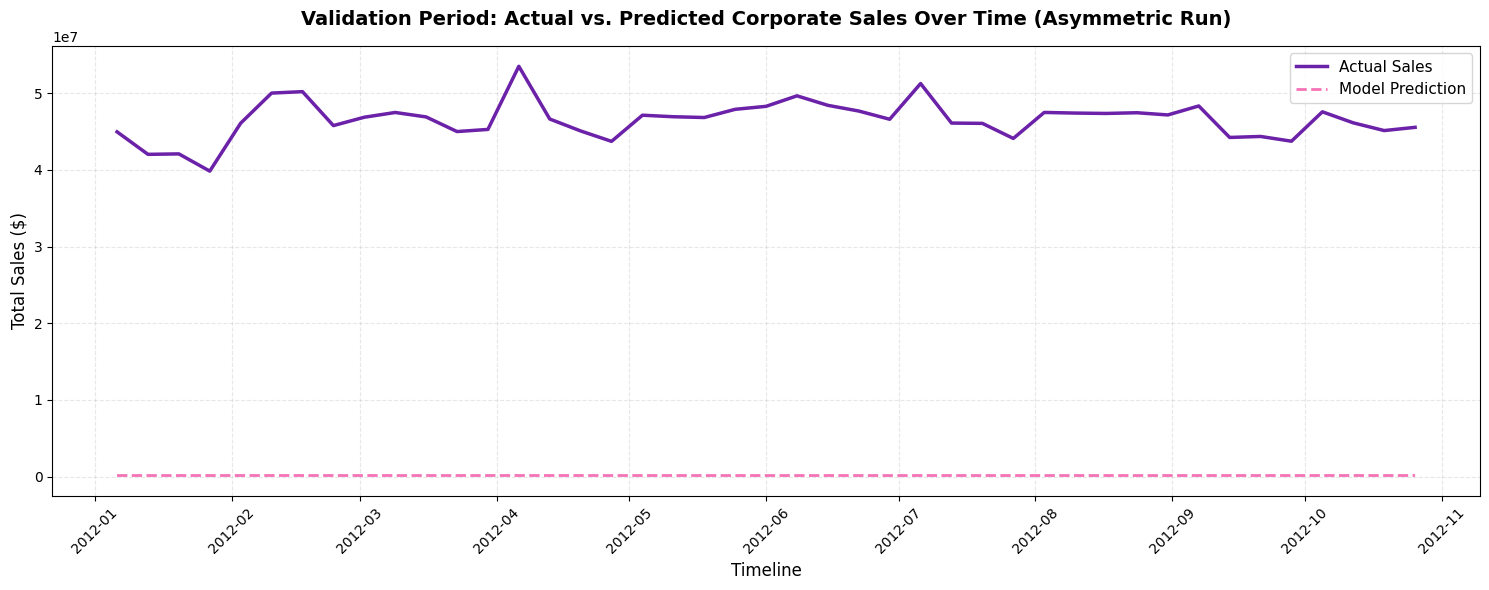

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

val_timeline = pd.DataFrame({
    'Date': pd.to_datetime(X_val_raw['Date']),
    'Actual': y_val,
    'Predicted': y_pred
})

val_timeline = val_timeline.groupby('Date').sum().reset_index()
val_timeline = val_timeline.sort_values('Date')

plt.figure(figsize=(15, 6))

# Plot Actuals
plt.plot(
    val_timeline['Date'],
    val_timeline['Actual'],
    color='#6b21a8',
    linewidth=2.5,
    label='Actual Sales'
)

# Plot Predictions
plt.plot(
    val_timeline['Date'],
    val_timeline['Predicted'],
    color='#f472b6',
    linewidth=2,
    linestyle='--',
    label='Model Prediction'
)

plt.title('Validation Period: Actual vs. Predicted Corporate Sales Over Time (Asymmetric Run)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

?????????

ვაიმე

In [56]:
train_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/train.csv.zip')
features_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/features.csv.zip')
stores_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/stores.csv')

splitter = TimeSeriesSplitter(split_date='2012-01-01')
train_raw_df = train_df[train_df['Date'] < '2012-01-01'].copy()
val_raw_df = train_df[train_df['Date'] >= '2012-01-01'].copy()

transformer = WalmartDataTransformer(features_df=features_df, stores_df=stores_df)
transformer.fit(train_raw_df, y=train_raw_df['Weekly_Sales'])

train_processed = transformer.transform(train_raw_df)
val_processed = transformer.transform(val_raw_df)

X_val_raw = val_processed.copy()

y_train = train_processed['Weekly_Sales']
y_val = val_processed['Weekly_Sales']

features_to_drop = ['Weekly_Sales', 'Date']
X_train = train_processed.drop(columns=features_to_drop, errors='ignore')
X_val = val_processed.drop(columns=features_to_drop, errors='ignore')

print(f"Perfectly aligned Train Matrix: {X_train.shape}, Target: {y_train.shape}")
print(f"Perfectly aligned Validation Matrix: {X_val.shape}, Target: {y_val.shape}")

Perfectly aligned Train Matrix: (294132, 20), Target: (294132,)
Perfectly aligned Validation Matrix: (127438, 20), Target: (127438,)


თავიდან მთლიანად


trains davulogav wina sauketesosac


In [57]:
import lightgbm as lgb
import mlflow.lightgbm
import numpy as np
import pandas as pd

features_to_use = [col for col in train_processed.columns if col not in ['Date', 'Weekly_Sales', 'Year']]

X_train_final = train_processed[features_to_use].copy()
X_val_final = val_processed[features_to_use].copy()

y_train = train_processed['Weekly_Sales']
y_val = val_processed['Weekly_Sales']

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_MAE_Regularized_Logged"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_final, y_train,
        eval_set=[(X_val_final, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    y_train_pred = model.predict(X_train_final)
    train_weights = X_train_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

    y_val_pred = model.predict(X_val_final)
    val_weights = X_val_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)

    y_pred = y_val_pred

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="model")

    print(f"Train WMAE: {train_wmae:.2f}")
    print(f"Validation WMAE: {val_wmae:.2f}")

2026/07/11 18:19:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train WMAE: 2044.26
Validation WMAE: 1759.24
🏃 View run LGBM_MAE_Regularized_Logged at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/439102fe0f9147de8125e38c0ed4c4fe
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


monacemebs aghar vaxleb xels

In [58]:
import lightgbm as lgb
import mlflow.lightgbm
import numpy as np
import pandas as pd

features_to_use = [col for col in train_processed.columns if col not in ['Date', 'Weekly_Sales', 'Year']]

X_train_final = train_processed[features_to_use].copy()
X_val_final = val_processed[features_to_use].copy()

y_train = train_processed['Weekly_Sales']
y_val = val_processed['Weekly_Sales']

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_Deep_Trees_Tuned"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1500,
        learning_rate=0.03,
        num_leaves=127,
        min_data_in_leaf=10,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_final, y_train,
        eval_set=[(X_val_final, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )


    y_train_pred = model.predict(X_train_final)
    train_weights = X_train_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

    y_val_pred = model.predict(X_val_final)
    val_weights = X_val_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)

    y_pred = y_val_pred

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="model")

    print(f"train {train_wmae:.2f}")
    print(f"val {val_wmae:.2f}")

2026/07/11 18:21:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


train 1932.21
val 1761.92
🏃 View run LGBM_Deep_Trees_Tuned at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/e922f43743544a80be1812272480091e
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


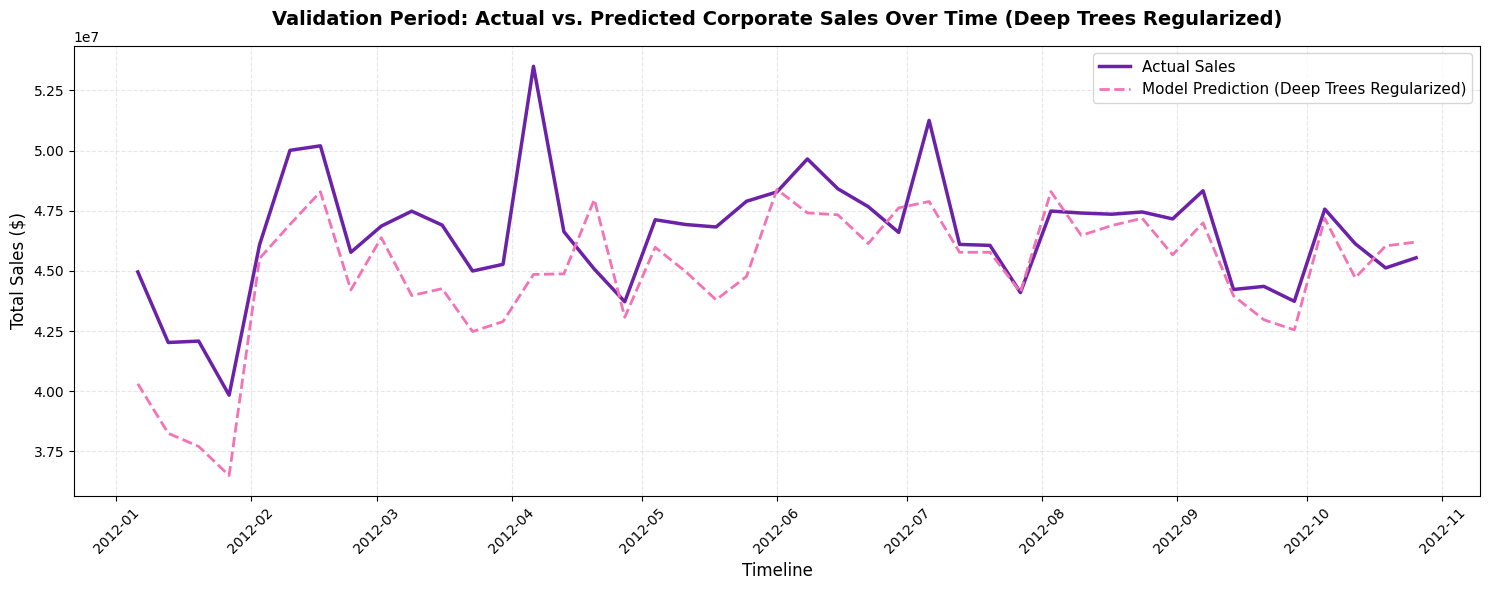

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

val_timeline = pd.DataFrame({
    'Date': pd.to_datetime(val_processed['Date']),
    'Actual': y_val,
    'Predicted': y_pred
})

val_timeline = val_timeline.groupby('Date').sum().reset_index()
val_timeline = val_timeline.sort_values('Date')

plt.figure(figsize=(15, 6))

plt.plot(
    val_timeline['Date'],
    val_timeline['Actual'],
    color='#6b21a8',
    linewidth=2.5,
    label='Actual Sales'
)

plt.plot(
    val_timeline['Date'],
    val_timeline['Predicted'],
    color='#f472b6',
    linewidth=2,
    linestyle='--',
    label='Model Prediction (Deep Trees Regularized)'
)

plt.title('Validation Period: Actual vs. Predicted Corporate Sales Over Time (Deep Trees Regularized)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [61]:
import lightgbm as lgb
import mlflow.lightgbm
import numpy as np
import pandas as pd

features_to_use = [col for col in train_processed.columns if col not in ['Date', 'Weekly_Sales', 'Year']]

X_train_final = train_processed[features_to_use].copy()
X_val_final = val_processed[features_to_use].copy()

y_train = train_processed['Weekly_Sales']
y_val = val_processed['Weekly_Sales']

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_Deep_Trees_Regularized"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1500,
        learning_rate=0.03,
        num_leaves=127,
        min_data_in_leaf=10,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        reg_alpha=5.0,
        reg_lambda=5.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_final, y_train,
        eval_set=[(X_val_final, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )


    y_train_pred = model.predict(X_train_final)
    train_weights = X_train_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

    y_val_pred = model.predict(X_val_final)
    val_weights = X_val_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)

    y_pred = y_val_pred

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="model")

    print(f"train {train_wmae:.2f}")
    print(f"val {val_wmae:.2f}")

2026/07/11 18:27:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


train 1802.76
val 1749.00
🏃 View run LGBM_Deep_Trees_Regularized at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/bb5dcc28c5bd4128bd1b784edc8a6d61
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


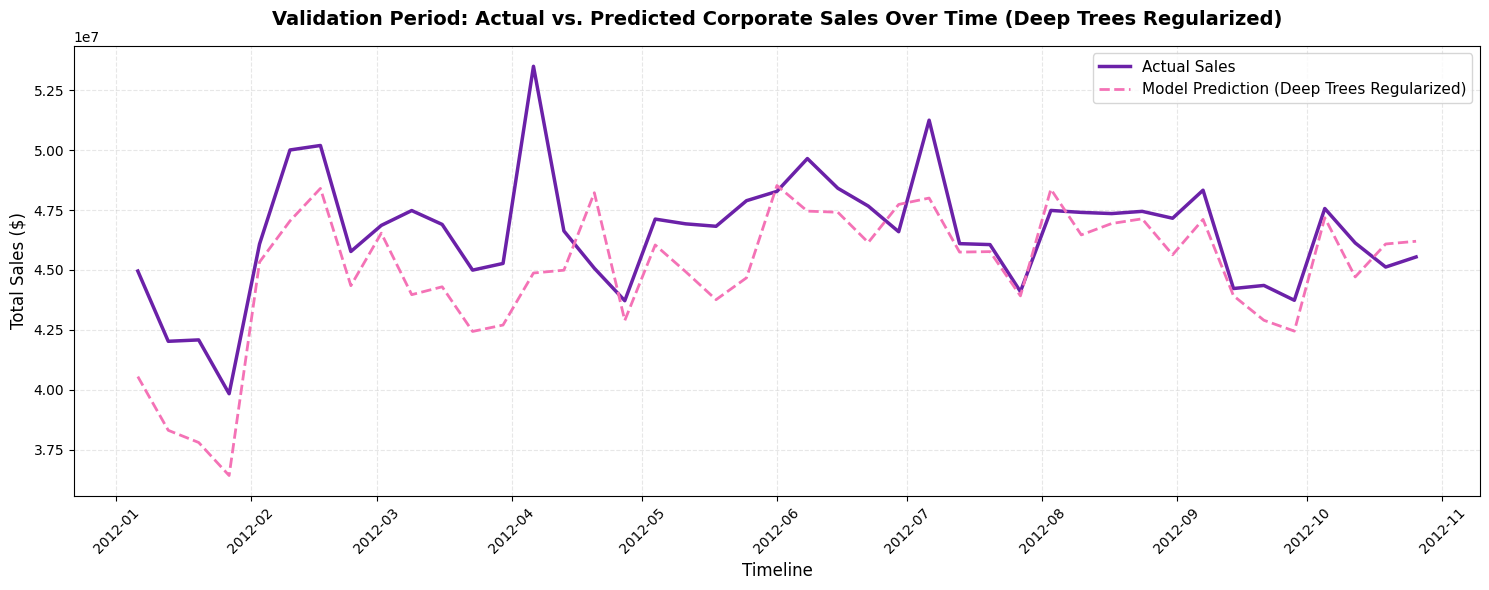

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

val_timeline = pd.DataFrame({
    'Date': pd.to_datetime(val_processed['Date']),
    'Actual': y_val,
    'Predicted': y_pred
})

val_timeline = val_timeline.groupby('Date').sum().reset_index()
val_timeline = val_timeline.sort_values('Date')

plt.figure(figsize=(15, 6))

plt.plot(
    val_timeline['Date'],
    val_timeline['Actual'],
    color='#6b21a8',
    linewidth=2.5,
    label='Actual Sales'
)

plt.plot(
    val_timeline['Date'],
    val_timeline['Predicted'],
    color='#f472b6',
    linewidth=2,
    linestyle='--',
    label='Model Prediction (Deep Trees Regularized)'
)

plt.title('Validation Period: Actual vs. Predicted Corporate Sales Over Time (Deep Trees Regularized)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [63]:
import lightgbm as lgb
import mlflow.lightgbm
import numpy as np
import pandas as pd


features_to_use = [col for col in train_processed.columns if col not in ['Date', 'Weekly_Sales', 'Year']]

X_train_final = train_processed[features_to_use].copy()
X_val_final = val_processed[features_to_use].copy()

y_train = train_processed['Weekly_Sales']
y_val = val_processed['Weekly_Sales']

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_Max_Capacity_Trees"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=255,
        min_data_in_leaf=10,
        feature_fraction=0.75,
        bagging_fraction=0.8,
        bagging_freq=1,
        reg_alpha=10.0,
        reg_lambda=10.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_final, y_train,
        eval_set=[(X_val_final, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )


    y_train_pred = model.predict(X_train_final)
    train_weights = X_train_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

    y_val_pred = model.predict(X_val_final)
    val_weights = X_val_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)
    y_pred = y_val_pred

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="model")

    print(f"train {train_wmae:.2f}")
    print(f"val {val_wmae:.2f}")

2026/07/11 18:32:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


train 1571.19
val 1721.54
🏃 View run LGBM_Max_Capacity_Trees at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/c9489ae1623e4eb39c3f2a7f299917a5
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


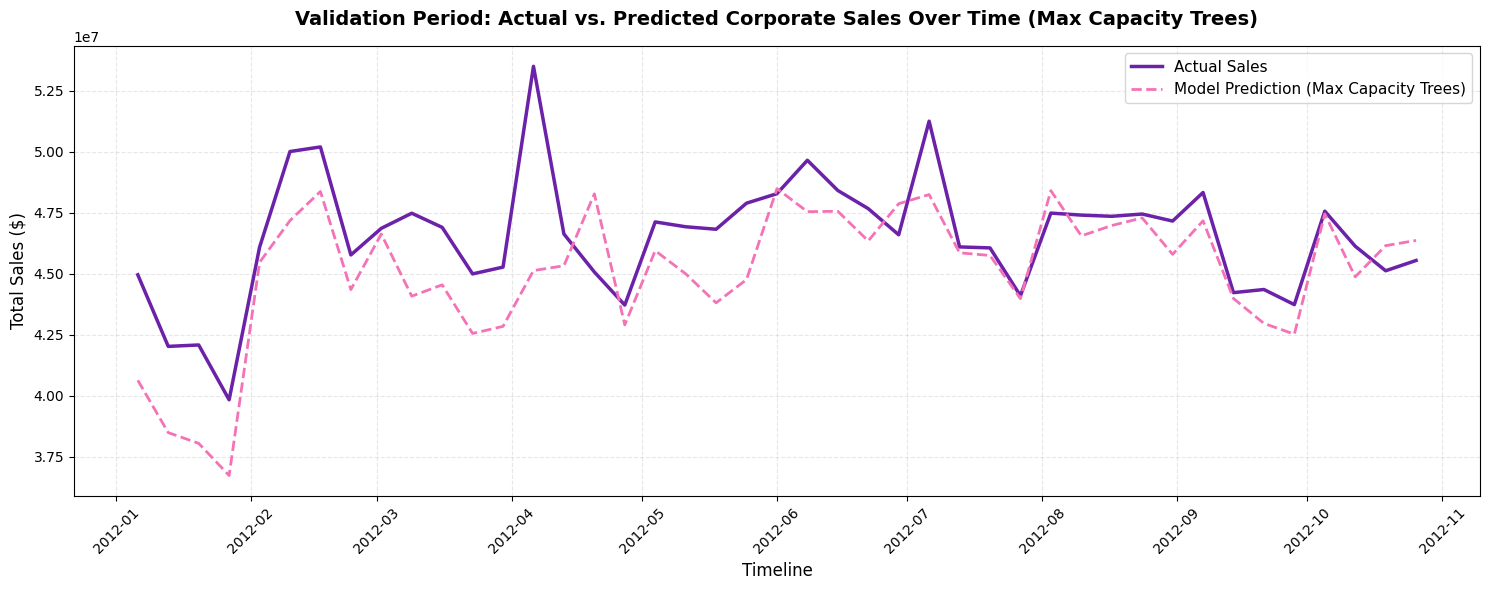

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

val_timeline = pd.DataFrame({
    'Date': pd.to_datetime(val_processed['Date']),
    'Actual': y_val,
    'Predicted': y_pred
})

val_timeline = val_timeline.groupby('Date').sum().reset_index()
val_timeline = val_timeline.sort_values('Date')

plt.figure(figsize=(15, 6))


plt.plot(
    val_timeline['Date'],
    val_timeline['Actual'],
    color='#6b21a8',
    linewidth=2.5,
    label='Actual Sales'
)

plt.plot(
    val_timeline['Date'],
    val_timeline['Predicted'],
    color='#f472b6',
    linewidth=2,
    linestyle='--',
    label='Model Prediction (Max Capacity Trees)'
)

plt.title('Validation Period: Actual vs. Predicted Corporate Sales Over Time (Max Capacity Trees)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [68]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/train.csv.zip')
features_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/features.csv.zip')
stores_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/stores.csv')

train_df['Date'] = pd.to_datetime(train_df['Date'])

train_raw_df = train_df[train_df['Date'] < '2011-09-01'].copy()
val_raw_df = train_df[train_df['Date'] >= '2011-09-01'].copy()


transformer = WalmartDataTransformer(features_df=features_df, stores_df=stores_df)
transformer.fit(train_raw_df, y=train_raw_df['Weekly_Sales'])

train_processed = transformer.transform(train_raw_df)
val_processed = transformer.transform(val_raw_df)

train_processed['Is_Pre_Holiday'] = train_processed.groupby(['Store', 'Dept'])['IsHoliday'].shift(-1).fillna(0).astype(int)
train_processed['Is_Post_Holiday'] = train_processed.groupby(['Store', 'Dept'])['IsHoliday'].shift(1).fillna(0).astype(int)

val_processed['Is_Pre_Holiday'] = val_processed.groupby(['Store', 'Dept'])['IsHoliday'].shift(-1).fillna(0).astype(int)
val_processed['Is_Post_Holiday'] = val_processed.groupby(['Store', 'Dept'])['IsHoliday'].shift(1).fillna(0).astype(int)

easter_dates = pd.to_datetime(['2010-04-04', '2011-04-24', '2012-04-08', '2013-03-31'])

def calculate_days_to_easter(df_date_col):
    dates = pd.to_datetime(df_date_col)
    distances = []
    for d in dates:
        diffs = [(easter - d).days for easter in easter_dates]
        future_diffs = [diff for diff in diffs if diff >= -7]
        distances.append(min(future_diffs) if future_diffs else 365)
    return distances

train_processed['Days_To_Easter'] = calculate_days_to_easter(train_processed['Date'])
val_processed['Days_To_Easter'] = calculate_days_to_easter(val_processed['Date'])

print(f"Data ready. Train shape: {train_processed.shape}, Val shape: {val_processed.shape}")

Data ready. Train shape: (240603, 25), Val shape: (180967, 25)


In [69]:
import lightgbm as lgb
import mlflow.lightgbm

features_to_use = [col for col in train_processed.columns if col not in ['Date', 'Weekly_Sales', 'Year']]

X_train_final = train_processed[features_to_use].copy()
X_val_final = val_processed[features_to_use].copy()

y_train = train_processed['Weekly_Sales']
y_val = val_processed['Weekly_Sales']

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_Easter_Proximity_Tuned"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=2500,
        learning_rate=0.03,
        num_leaves=255,
        min_data_in_leaf=10,
        feature_fraction=0.75,
        bagging_fraction=0.8,
        bagging_freq=1,
        reg_alpha=10.0,
        reg_lambda=10.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_final, y_train,
        eval_set=[(X_val_final, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    y_train_pred = model.predict(X_train_final)
    train_weights = X_train_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

    y_val_pred = model.predict(X_val_final)
    val_weights = X_val_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)

    y_pred = y_val_pred

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)
    mlflow.lightgbm.log_model(model, name="model")

    print(f"Train WMAE: {train_wmae:.2f}")
    print(f"Validation WMAE: {val_wmae:.2f}")

Train WMAE: 1748.10
Validation WMAE: 2316.63
🏃 View run LGBM_Easter_Proximity_Tuned at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/0a2f3107427948289f4c8a8883a9ef37
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


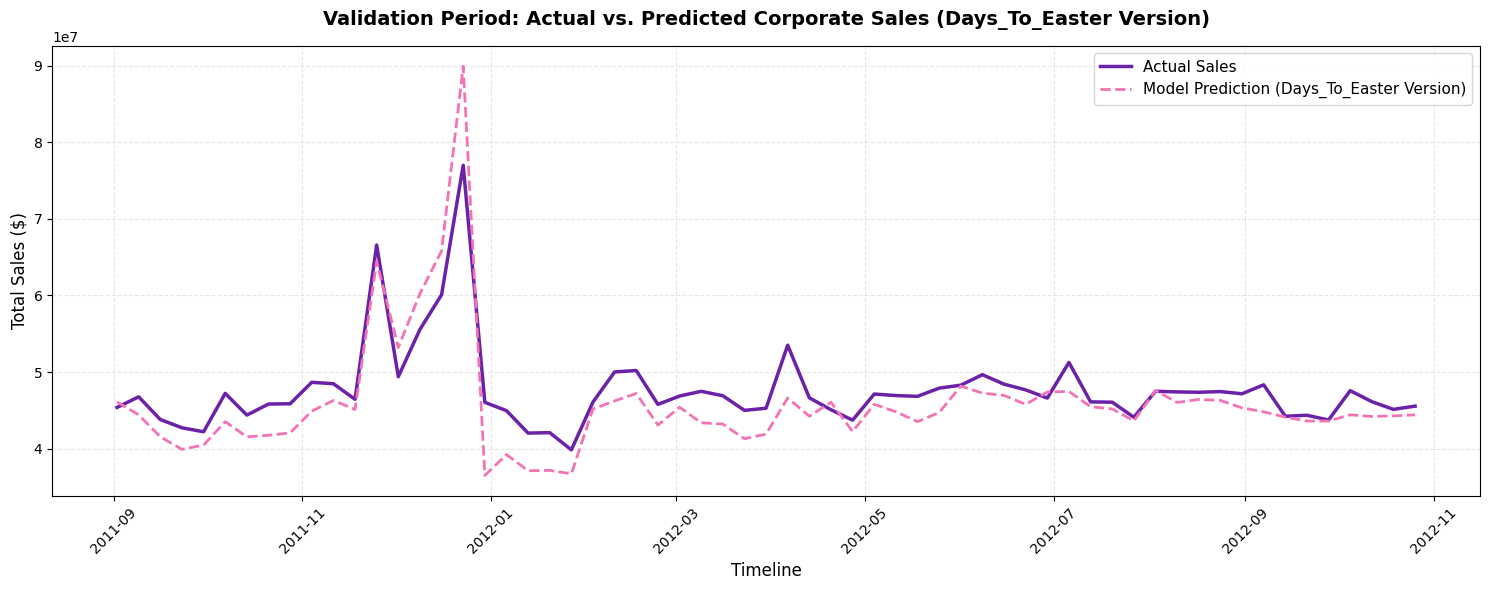

In [72]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import lightgbm as lgb

features_to_use = [col for col in train_processed.columns if col not in ['Date', 'Weekly_Sales', 'Year', 'Is_Easter_Week']]

X_train_temp = train_processed[features_to_use].copy()
X_val_temp = val_processed[features_to_use].copy()

easter_dates = pd.to_datetime(['2010-04-04', '2011-04-24', '2012-04-08', '2013-03-31'])
def calculate_days_to_easter(df_date_col):
    dates = pd.to_datetime(df_date_col)
    distances = []
    for d in dates:
        diffs = [(easter - d).days for easter in easter_dates]
        future_diffs = [diff for diff in diffs if diff >= -7]
        distances.append(min(future_diffs) if future_diffs else 365)
    return distances

X_train_temp['Days_To_Easter'] = calculate_days_to_easter(train_processed['Date'])
X_val_temp['Days_To_Easter'] = calculate_days_to_easter(val_processed['Date'])

for col in X_train_temp.columns:
    if X_train_temp[col].dtype == 'object':
        X_train_temp[col] = X_train_temp[col].astype('category')
        X_val_temp[col] = X_val_temp[col].astype('category')

temp_model = lgb.LGBMRegressor(
    objective='mae', n_estimators=2000, learning_rate=0.03, num_leaves=255,
    min_data_in_leaf=10, feature_fraction=0.75, bagging_fraction=0.8, bagging_freq=1,
    reg_alpha=10.0, reg_lambda=10.0, random_state=42, n_jobs=-1, verbose=-1
)
temp_model.fit(X_train_temp, y_train, eval_set=[(X_val_temp, y_val)], callbacks=[lgb.early_stopping(40, verbose=False)])
y_pred_easter_days = temp_model.predict(X_val_temp)

val_timeline = pd.DataFrame({
    'Date': pd.to_datetime(val_processed['Date']),
    'Actual': y_val,
    'Predicted': y_pred_easter_days
})
val_timeline = val_timeline.groupby('Date').sum().reset_index().sort_values('Date')

plt.figure(figsize=(15, 6))
plt.plot(val_timeline['Date'], val_timeline['Actual'], color='#6b21a8', linewidth=2.5, label='Actual Sales')
plt.plot(val_timeline['Date'], val_timeline['Predicted'], color='#f472b6', linewidth=2, linestyle='--', label='Model Prediction (Days_To_Easter Version)')

plt.title('Validation Period: Actual vs. Predicted Corporate Sales (Days_To_Easter Version)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [71]:
print ("lalala")

lalala


In [73]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/train.csv.zip')
features_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/features.csv.zip')
stores_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/stores.csv')

train_df['Date'] = pd.to_datetime(train_df['Date'])

train_raw_df = train_df[train_df['Date'] < '2011-09-01'].copy()
val_raw_df = train_df[train_df['Date'] >= '2011-09-01'].copy()

transformer = WalmartDataTransformer(features_df=features_df, stores_df=stores_df)
transformer.fit(train_raw_df, y=train_raw_df['Weekly_Sales'])

train_processed = transformer.transform(train_raw_df)
val_processed = transformer.transform(val_raw_df)


train_processed['Is_Pre_Holiday'] = train_processed.groupby(['Store', 'Dept'])['IsHoliday'].shift(-1).fillna(0).astype(int)
train_processed['Is_Post_Holiday'] = train_processed.groupby(['Store', 'Dept'])['IsHoliday'].shift(1).fillna(0).astype(int)

val_processed['Is_Pre_Holiday'] = val_processed.groupby(['Store', 'Dept'])['IsHoliday'].shift(-1).fillna(0).astype(int)
val_processed['Is_Post_Holiday'] = val_processed.groupby(['Store', 'Dept'])['IsHoliday'].shift(1).fillna(0).astype(int)


easter_weeks = {2010: 13, 2011: 16, 2012: 14, 2013: 13}

train_processed['Is_Easter_Week'] = train_processed.apply(lambda row: 1 if easter_weeks.get(row['Date'].year) == row['Week'] else 0, axis=1)
val_processed['Is_Easter_Week'] = val_processed.apply(lambda row: 1 if easter_weeks.get(row['Date'].year) == row['Week'] else 0, axis=1)

print(f"Data ready. Train shape: {train_processed.shape}, Val shape: {val_processed.shape}")

Data ready. Train shape: (240603, 25), Val shape: (180967, 25)


In [74]:
import lightgbm as lgb
import mlflow.lightgbm

features_to_use = [col for col in train_processed.columns if col not in ['Date', 'Weekly_Sales', 'Year']]

X_train_final = train_processed[features_to_use].copy()
X_val_final = val_processed[features_to_use].copy()

y_train = train_processed['Weekly_Sales']
y_val = val_processed['Weekly_Sales']

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_Max_Capacity_Easter_Fixed"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=255,
        min_data_in_leaf=10,
        feature_fraction=0.75,
        bagging_fraction=0.8,
        bagging_freq=1,
        reg_alpha=10.0,
        reg_lambda=10.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_final, y_train,
        eval_set=[(X_val_final, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )

    y_train_pred = model.predict(X_train_final)
    train_weights = X_train_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

    y_val_pred = model.predict(X_val_final)
    val_weights = X_val_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)

    y_pred = y_val_pred

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)
    mlflow.lightgbm.log_model(model, name="model")

    print(f"Train WMAE: {train_wmae:.2f}")
    print(f"Validation WMAE: {val_wmae:.2f}")

Train WMAE: 1933.86
Validation WMAE: 2325.45
🏃 View run LGBM_Max_Capacity_Easter_Fixed at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/fc0ba4c9a9b54e03a8f24a13290d9f0e
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


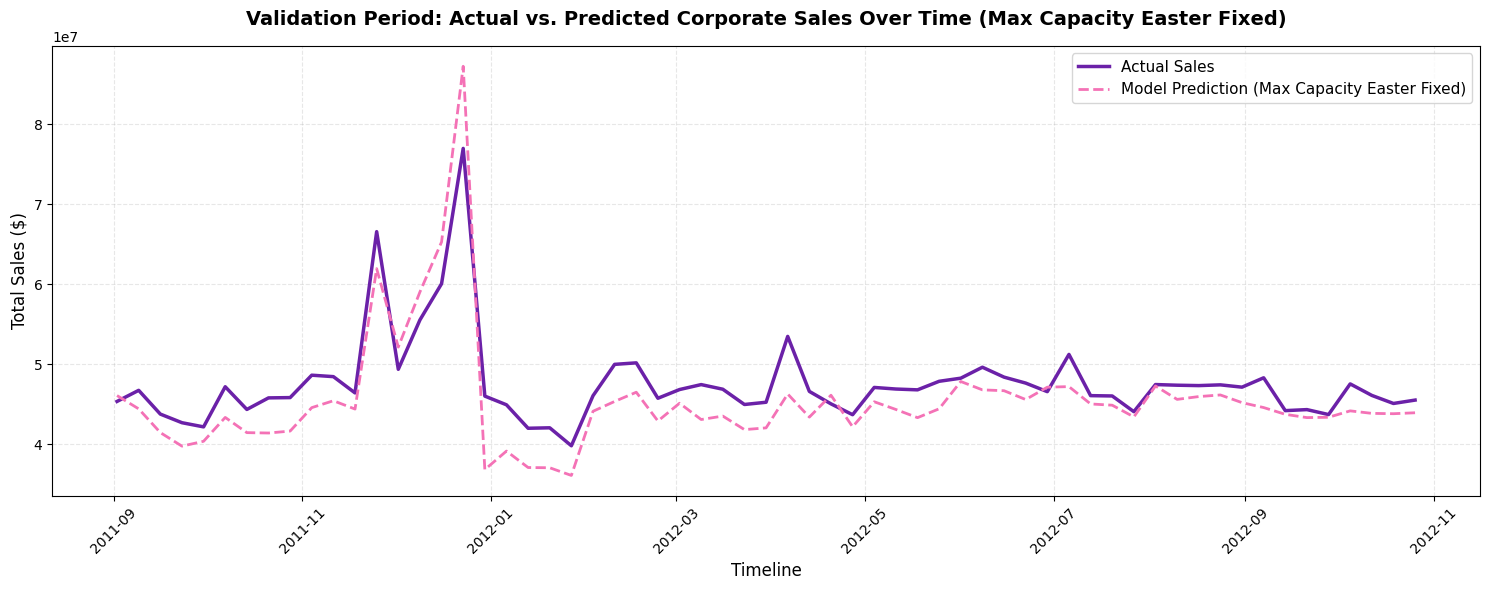

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

val_timeline = pd.DataFrame({
    'Date': pd.to_datetime(val_processed['Date']),
    'Actual': y_val,
    'Predicted': y_pred
})

val_timeline = val_timeline.groupby('Date').sum().reset_index()
val_timeline = val_timeline.sort_values('Date')

plt.figure(figsize=(15, 6))

plt.plot(
    val_timeline['Date'],
    val_timeline['Actual'],
    color='#6b21a8',
    linewidth=2.5,
    label='Actual Sales'
)

plt.plot(
    val_timeline['Date'],
    val_timeline['Predicted'],
    color='#f472b6',
    linewidth=2,
    linestyle='--',
    label='Model Prediction (Max Capacity Easter Fixed)'
)

plt.title('Validation Period: Actual vs. Predicted Corporate Sales Over Time (Max Capacity Easter Fixed)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [76]:
import lightgbm as lgb
import mlflow.lightgbm
import numpy as np
import pandas as pd

features_to_use = [col for col in train_processed.columns if col not in ['Date', 'Weekly_Sales', 'Year']]

X_train_final = train_processed[features_to_use].copy()
X_val_final = val_processed[features_to_use].copy()

y_train = train_processed['Weekly_Sales']
y_val = val_processed['Weekly_Sales']

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_Regularized_Holiday_Balanced"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=127,
        min_data_in_leaf=30,
        feature_fraction=0.75,
        bagging_fraction=0.8,
        bagging_freq=1,
        reg_alpha=15.0,
        reg_lambda=25.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_final, y_train,
        eval_set=[(X_val_final, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )

    y_train_pred = model.predict(X_train_final)
    train_weights = X_train_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

    y_val_pred = model.predict(X_val_final)
    val_weights = X_val_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)

    y_pred = y_val_pred

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)
    mlflow.lightgbm.log_model(model, name="model")

    print(f"Train WMAE: {train_wmae:.2f}")
    print(f"Validation WMAE: {val_wmae:.2f}")

Train WMAE: 2077.21
Validation WMAE: 2320.30
🏃 View run LGBM_Regularized_Holiday_Balanced at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/31a50dfd6f5c485dbfcf1a9146a78999
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


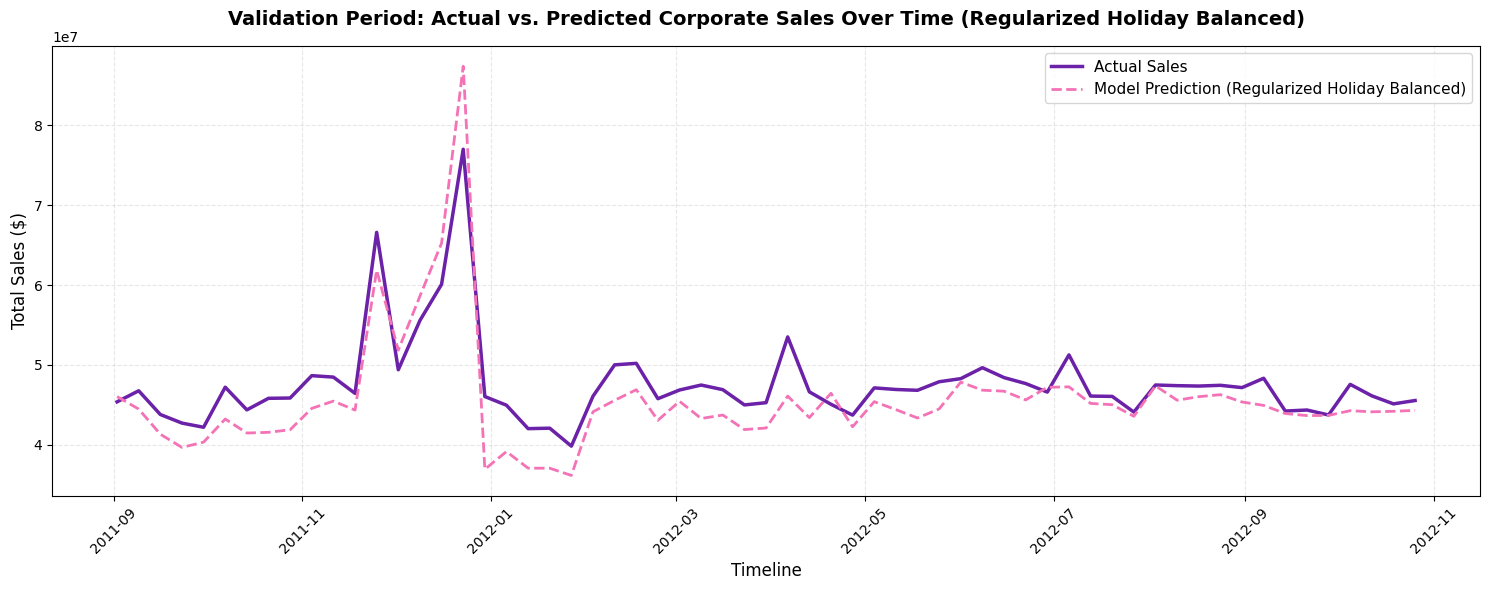

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

val_timeline = pd.DataFrame({
    'Date': pd.to_datetime(val_processed['Date']),
    'Actual': y_val,
    'Predicted': y_pred
})

val_timeline = val_timeline.groupby('Date').sum().reset_index()
val_timeline = val_timeline.sort_values('Date')

plt.figure(figsize=(15, 6))

plt.plot(
    val_timeline['Date'],
    val_timeline['Actual'],
    color='#6b21a8',
    linewidth=2.5,
    label='Actual Sales'
)

plt.plot(
    val_timeline['Date'],
    val_timeline['Predicted'],
    color='#f472b6',
    linewidth=2,
    linestyle='--',
    label='Model Prediction (Regularized Holiday Balanced)'
)

plt.title('Validation Period: Actual vs. Predicted Corporate Sales Over Time (Regularized Holiday Balanced)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [78]:
import lightgbm as lgb
import mlflow.lightgbm
import numpy as np
import pandas as pd

features_to_use = [col for col in train_processed.columns if col not in ['Date', 'Weekly_Sales', 'Year']]

X_train_final = train_processed[features_to_use].copy()
X_val_final = val_processed[features_to_use].copy()

y_train = train_processed['Weekly_Sales']
y_val = val_processed['Weekly_Sales']

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')


fit_weights = X_train_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_Weighted_Loss_Balanced"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=127,
        min_data_in_leaf=30,
        feature_fraction=0.75,
        bagging_fraction=0.8,
        bagging_freq=1,
        reg_alpha=15.0,
        reg_lambda=25.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_final, y_train,
        sample_weight=fit_weights,
        eval_set=[(X_val_final, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )

    y_train_pred = model.predict(X_train_final)
    train_weights = X_train_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

    y_val_pred = model.predict(X_val_final)
    val_weights = X_val_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)

    y_pred = y_val_pred

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)
    mlflow.lightgbm.log_model(model, name="model")

    print(f"Train WMAE: {train_wmae:.2f}")
    print(f"Validation WMAE: {val_wmae:.2f}")

Train WMAE: 1973.41
Validation WMAE: 2344.28
🏃 View run LGBM_Weighted_Loss_Balanced at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/9794e11b55df446f931d6b84c3090ad2
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


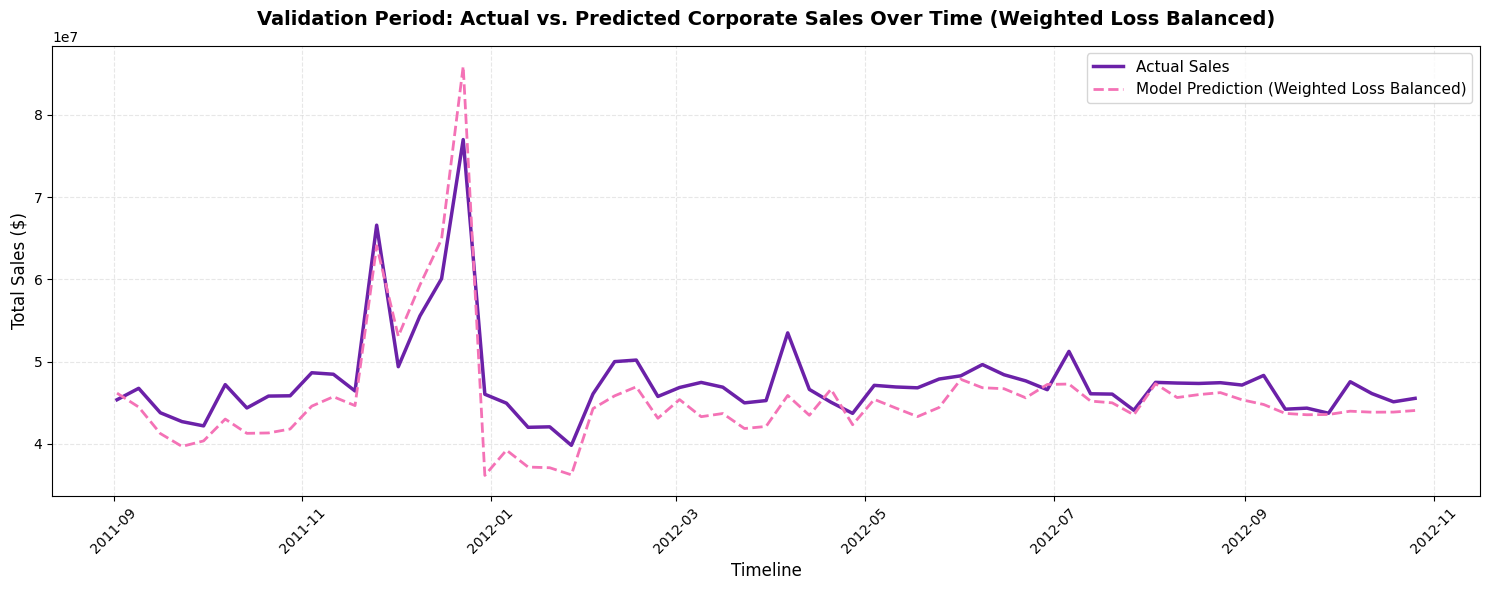

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

val_timeline = pd.DataFrame({
    'Date': pd.to_datetime(val_processed['Date']),
    'Actual': y_val,
    'Predicted': y_pred
})

val_timeline = val_timeline.groupby('Date').sum().reset_index()
val_timeline = val_timeline.sort_values('Date')

plt.figure(figsize=(15, 6))

plt.plot(
    val_timeline['Date'],
    val_timeline['Actual'],
    color='#6b21a8',
    linewidth=2.5,
    label='Actual Sales'
)


plt.plot(
    val_timeline['Date'],
    val_timeline['Predicted'],
    color='#f472b6',
    linewidth=2,
    linestyle='--',
    label='Model Prediction (Weighted Loss Balanced)'
)

plt.title('Validation Period: Actual vs. Predicted Corporate Sales Over Time (Weighted Loss Balanced)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [80]:
import lightgbm as lgb
import mlflow.lightgbm
import numpy as np
import pandas as pd

features_to_use = [col for col in train_processed.columns if col not in ['Date', 'Weekly_Sales', 'Year', 'Is_Easter_Week']]

X_train_final = train_processed[features_to_use].copy()
X_val_final = val_processed[features_to_use].copy()

y_train = train_processed['Weekly_Sales']
y_val = val_processed['Weekly_Sales']

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')

fit_weights = X_train_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_Huber_Objective_Final"):

    model = lgb.LGBMRegressor(
        objective='huber',
        n_estimators=1500,
        learning_rate=0.05,
        num_leaves=63,
        min_data_in_leaf=20,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        reg_alpha=5.0,
        reg_lambda=15.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_final, y_train,
        sample_weight=fit_weights,
        eval_set=[(X_val_final, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )

    y_train_pred = model.predict(X_train_final)
    train_weights = X_train_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

    y_val_pred = model.predict(X_val_final)
    val_weights = X_val_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)

    y_pred = y_val_pred

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)
    mlflow.lightgbm.log_model(model, name="model")

    print(f"Train WMAE: {train_wmae:.2f}")
    print(f"Validation WMAE: {val_wmae:.2f}")

Train WMAE: 15167.55
Validation WMAE: 15525.95
🏃 View run LGBM_Huber_Objective_Final at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/12719416f9724b63bd2866e6b1b2262b
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


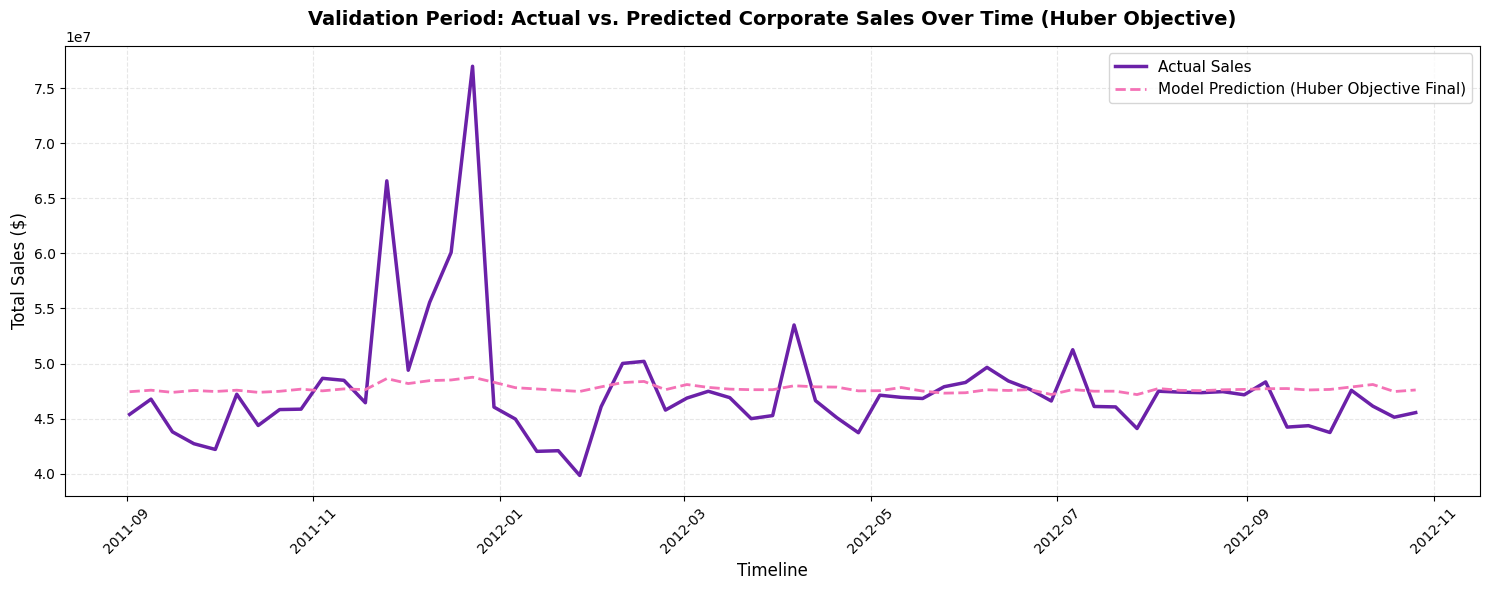

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

val_timeline = pd.DataFrame({
    'Date': pd.to_datetime(val_processed['Date']),
    'Actual': y_val,
    'Predicted': y_pred
})

val_timeline = val_timeline.groupby('Date').sum().reset_index()
val_timeline = val_timeline.sort_values('Date')

plt.figure(figsize=(15, 6))

plt.plot(
    val_timeline['Date'],
    val_timeline['Actual'],
    color='#6b21a8',
    linewidth=2.5,
    label='Actual Sales'
)

plt.plot(
    val_timeline['Date'],
    val_timeline['Predicted'],
    color='#f472b6',
    linewidth=2,
    linestyle='--',
    label='Model Prediction (Huber Objective Final)'
)

plt.title('Validation Period: Actual vs. Predicted Corporate Sales Over Time (Huber Objective)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [82]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/train.csv.zip')
features_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/features.csv.zip')
stores_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/stores.csv')

train_df['Date'] = pd.to_datetime(train_df['Date'])

train_raw_df = train_df[train_df['Date'] < '2011-09-01'].copy()
val_raw_df = train_df[train_df['Date'] >= '2011-09-01'].copy()

transformer = WalmartDataTransformer(features_df=features_df, stores_df=stores_df)
transformer.fit(train_raw_df, y=train_raw_df['Weekly_Sales'])

train_processed = transformer.transform(train_raw_df)
val_processed = transformer.transform(val_raw_df)

train_processed['Is_Pre_Holiday'] = train_processed.groupby(['Store', 'Dept'])['IsHoliday'].shift(-1).fillna(0).astype(int)
train_processed['Is_Post_Holiday'] = train_processed.groupby(['Store', 'Dept'])['IsHoliday'].shift(1).fillna(0).astype(int)

val_processed['Is_Pre_Holiday'] = val_processed.groupby(['Store', 'Dept'])['IsHoliday'].shift(-1).fillna(0).astype(int)
val_processed['Is_Post_Holiday'] = val_processed.groupby(['Store', 'Dept'])['IsHoliday'].shift(1).fillna(0).astype(int)

def label_holiday_type(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df['Holiday_Type'] = 'None'

    df.loc[(df['IsHoliday'] == 1) & (df['Week'].isin([6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17])), 'Holiday_Type'] = 'Easter'
    df.loc[(df['IsHoliday'] == 1) & (df['Week'].isin([35, 36, 37])), 'Holiday_Type'] = 'Labor_Day'
    df.loc[(df['IsHoliday'] == 1) & (df['Week'].isin([46, 47, 48])), 'Holiday_Type'] = 'Thanksgiving'
    df.loc[(df['IsHoliday'] == 1) & (df['Week'].isin([51, 52, 1])), 'Holiday_Type'] = 'Christmas'
    return df

train_processed = label_holiday_type(train_processed)
val_processed = label_holiday_type(val_processed)

print(f"Data ready. Train shape: {train_processed.shape}, Val shape: {val_processed.shape}")

Data ready. Train shape: (240603, 25), Val shape: (180967, 25)


In [83]:
import lightgbm as lgb
import mlflow.lightgbm

features_to_use = [col for col in train_processed.columns if col not in ['Date', 'Weekly_Sales', 'Year']]

X_train_final = train_processed[features_to_use].copy()
X_val_final = val_processed[features_to_use].copy()

y_train = train_processed['Weekly_Sales']
y_val = val_processed['Weekly_Sales']

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object' or col == 'Holiday_Type':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_Holiday_Named_Final"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=255,
        min_data_in_leaf=10,
        feature_fraction=0.75,
        bagging_fraction=0.8,
        bagging_freq=1,
        reg_alpha=10.0,
        reg_lambda=10.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_final, y_train,
        eval_set=[(X_val_final, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )

    y_train_pred = model.predict(X_train_final)
    train_weights = X_train_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

    y_val_pred = model.predict(X_val_final)
    val_weights = X_val_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)

    y_pred = y_val_pred

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)
    mlflow.lightgbm.log_model(model, name="model")

    print(f"Train WMAE: {train_wmae:.2f}")
    print(f"Validation WMAE: {val_wmae:.2f}")

Train WMAE: 1870.52
Validation WMAE: 2320.45
🏃 View run LGBM_Holiday_Named_Final at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/555f1ce5e9b9497da4e0edfe7a25c7a3
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


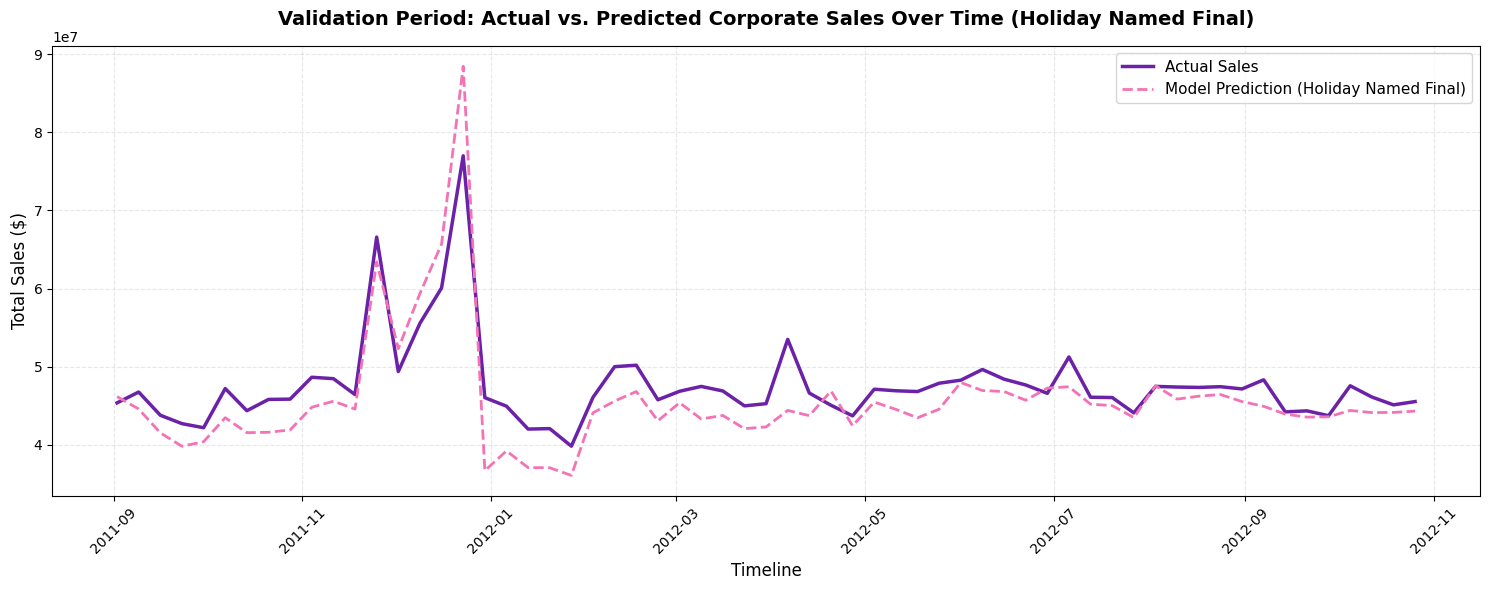

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

val_timeline = pd.DataFrame({
    'Date': pd.to_datetime(val_processed['Date']),
    'Actual': y_val,
    'Predicted': y_pred
})

val_timeline = val_timeline.groupby('Date').sum().reset_index()
val_timeline = val_timeline.sort_values('Date')

plt.figure(figsize=(15, 6))

plt.plot(
    val_timeline['Date'],
    val_timeline['Actual'],
    color='#6b21a8',
    linewidth=2.5,
    label='Actual Sales'
)

plt.plot(
    val_timeline['Date'],
    val_timeline['Predicted'],
    color='#f472b6',
    linewidth=2,
    linestyle='--',
    label='Model Prediction (Holiday Named Final)'
)

plt.title('Validation Period: Actual vs. Predicted Corporate Sales Over Time (Holiday Named Final)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [90]:
import lightgbm as lgb
import mlflow.lightgbm
import numpy as np
import pandas as pd
import pickle

features_to_use = [col for col in train_processed.columns if col not in ['Date', 'Weekly_Sales', 'Year']]

X_train_final = train_processed[features_to_use].copy()
X_val_final = val_processed[features_to_use].copy()

y_train = train_processed['Weekly_Sales']
y_val = val_processed['Weekly_Sales']

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_Max_Capacity_Trees"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=255,
        min_data_in_leaf=10,
        feature_fraction=0.75,
        bagging_fraction=0.8,
        bagging_freq=1,
        reg_alpha=10.0,
        reg_lambda=10.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_final, y_train,
        eval_set=[(X_val_final, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )

    y_train_pred = model.predict(X_train_final)
    train_weights = X_train_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

    y_val_pred = model.predict(X_val_final)
    val_weights = X_val_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)
    y_pred = y_val_pred

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="model")

    # Double down on safety by saving a hard file directly to your directory
    with open("walmart_lgbm_best_model.pkl", "wb") as f:
        pickle.dump(model, f)

    print(f"train {train_wmae:.2f}")
    print(f"val {val_wmae:.2f}")

2026/07/11 19:20:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


train 1922.62
val 2315.21
🏃 View run LGBM_Max_Capacity_Trees at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/29ef27725b7e491b934b3d2280f196cf
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


In [101]:
%%writefile transformers.py
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin


class WalmartDataTransformer(BaseEstimator, TransformerMixin):
    """
    IMPORTANT USAGE NOTE:
    Always call .fit() with the FULL available training history up to the
    point in time you're transforming from. For inference on the real test
    set (Nov 2012 - Jul 2013), fit on the ENTIRE train_df, not a pre-2012
    subset — otherwise sales_lag_52 falls back to a flat average for most
    of the test period instead of using real prior-year sales.
    """

    def __init__(self, features_df, stores_df):
        self.features_df = features_df.copy()
        self.stores_df = stores_df.copy()
        self.features_df['Date'] = pd.to_datetime(self.features_df['Date'])
        self._type_categories = sorted(self.stores_df['Type'].dropna().unique().tolist())

        self.history_df = None
        self.global_means = {}

    def fit(self, X, y=None):
        df = X.copy()
        if y is not None:
            df['Weekly_Sales'] = y

        df['Date'] = pd.to_datetime(df['Date'])

        if 'Weekly_Sales' in df.columns:
            self.history_df = df[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()
            self.global_means = df.groupby(['Store', 'Dept'])['Weekly_Sales'].mean().to_dict()

        return self

    def transform(self, X):
        df = X.copy()
        df['Date'] = pd.to_datetime(df['Date'])

        df = df.merge(self.stores_df, on='Store', how='left')
        df = df.merge(self.features_df, on=['Store', 'Date'], how='left')

        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month
        df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

        if 'IsHoliday_x' in df.columns:
            df['IsHoliday'] = df['IsHoliday_x'].astype(int)
        elif 'IsHoliday' in df.columns:
            df['IsHoliday'] = df['IsHoliday'].astype(int)

        if 'Type' in df.columns:
            df['Type'] = pd.Categorical(df['Type'], categories=self._type_categories).codes

        if self.history_df is not None:
            df['Date_lag_52'] = df['Date'] - pd.Timedelta(days=364)
            lag_52_df = self.history_df.rename(
                columns={'Date': 'Date_lag_52', 'Weekly_Sales': 'sales_lag_52'}
            )
            df = df.merge(lag_52_df, on=['Store', 'Dept', 'Date_lag_52'], how='left')
            df.drop(columns=['Date_lag_52'], inplace=True)

            store_dept_keys = list(zip(df['Store'], df['Dept']))
            fallback_vals = [self.global_means.get(key, 0) for key in store_dept_keys]
            df['sales_lag_52'] = df['sales_lag_52'].fillna(pd.Series(fallback_vals, index=df.index))
        else:
            df['sales_lag_52'] = 0

        # Sort before computing shift-based holiday proximity features,
        # so Is_Pre_Holiday / Is_Post_Holiday are consistent every time
        # this method runs (train, val, or test) instead of depending
        # on whatever order the caller passed rows in.
        df = df.sort_values(by=['Store', 'Dept', 'Date']).reset_index(drop=True)

        df['Is_Pre_Holiday'] = (
            df.groupby(['Store', 'Dept'])['IsHoliday']
            .shift(-1)
            .fillna(0)
            .astype(int)
        )
        df['Is_Post_Holiday'] = (
            df.groupby(['Store', 'Dept'])['IsHoliday']
            .shift(1)
            .fillna(0)
            .astype(int)
        )

        other_cols = [c for c in df.columns if c not in ['Weekly_Sales', 'sales_lag_52']]
        df[other_cols] = df[other_cols].fillna(0)

        return df


class TimeSeriesSplitter:
    def __init__(self, split_date='2012-01-01', target_col='Weekly_Sales', date_col='Date'):
        self.split_date = pd.to_datetime(split_date)
        self.target_col = target_col
        self.date_col = date_col

    def split(self, df):
        df = df.copy()
        df[self.date_col] = pd.to_datetime(df[self.date_col])
        df = df.sort_values(by=self.date_col).reset_index(drop=True)

        train_mask = df[self.date_col] < self.split_date
        val_mask = df[self.date_col] >= self.split_date

        train_data = df[train_mask].reset_index(drop=True)
        val_data = df[val_mask].reset_index(drop=True)

        y_train = train_data[self.target_col] if self.target_col in train_data.columns else None
        y_val = val_data[self.target_col] if self.target_col in val_data.columns else None

        features_to_drop = [self.target_col, 'IsHoliday_x', 'IsHoliday_y']
        X_train = train_data.drop(columns=features_to_drop, errors='ignore')
        X_val = val_data.drop(columns=features_to_drop, errors='ignore')

        return X_train, y_train, X_val, y_val

Overwriting transformers.py


In [102]:
import importlib
import transformers

importlib.reload(transformers)
from transformers import WalmartDataTransformer, TimeSeriesSplitter

print("Transformers module reloaded successfully.")

Transformers module reloaded successfully.


In [103]:
train_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/train.csv.zip')
features_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/features.csv.zip')
stores_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/stores.csv')

splitter = TimeSeriesSplitter(split_date='2012-01-01')
train_raw_df = train_df[train_df['Date'] < '2012-01-01'].copy()
val_raw_df = train_df[train_df['Date'] >= '2012-01-01'].copy()

transformer = WalmartDataTransformer(features_df=features_df, stores_df=stores_df)
transformer.fit(train_raw_df, y=train_raw_df['Weekly_Sales'])

train_processed = transformer.transform(train_raw_df)
val_processed = transformer.transform(val_raw_df)

X_val_raw = val_processed.copy()

y_train = train_processed['Weekly_Sales']
y_val = val_processed['Weekly_Sales']

features_to_drop = ['Weekly_Sales', 'Date']
X_train = train_processed.drop(columns=features_to_drop, errors='ignore')
X_val = val_processed.drop(columns=features_to_drop, errors='ignore')

print(f"Perfectly aligned Train Matrix: {X_train.shape}, Target: {y_train.shape}")
print(f"Perfectly aligned Validation Matrix: {X_val.shape}, Target: {y_val.shape}")

Perfectly aligned Train Matrix: (294132, 22), Target: (294132,)
Perfectly aligned Validation Matrix: (127438, 22), Target: (127438,)


In [110]:
import lightgbm as lgb
import mlflow.lightgbm
import numpy as np
import pandas as pd


features_to_use = [col for col in train_processed.columns if col not in ['Date', 'Weekly_Sales', 'Year']]

X_train_final = train_processed[features_to_use].copy()
X_val_final = val_processed[features_to_use].copy()

y_train = train_processed['Weekly_Sales']
y_val = val_processed['Weekly_Sales']

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_Max_Capacity_Trees_Final_F"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=255,
        min_data_in_leaf=10,
        feature_fraction=0.75,
        bagging_fraction=0.8,
        bagging_freq=1,
        reg_alpha=10.0,
        reg_lambda=10.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_final, y_train,
        eval_set=[(X_val_final, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )


    y_train_pred = model.predict(X_train_final)
    train_weights = X_train_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

    y_val_pred = model.predict(X_val_final)
    val_weights = X_val_final['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)
    y_pred = y_val_pred

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="Final_model")

    print(f"train {train_wmae:.2f}")
    print(f"val {val_wmae:.2f}")

2026/07/11 20:45:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


train 1613.79
val 1739.53
🏃 View run LGBM_Max_Capacity_Trees_Final_F at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/4f9503eef44e4cc7bde3a5679bdeb624
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


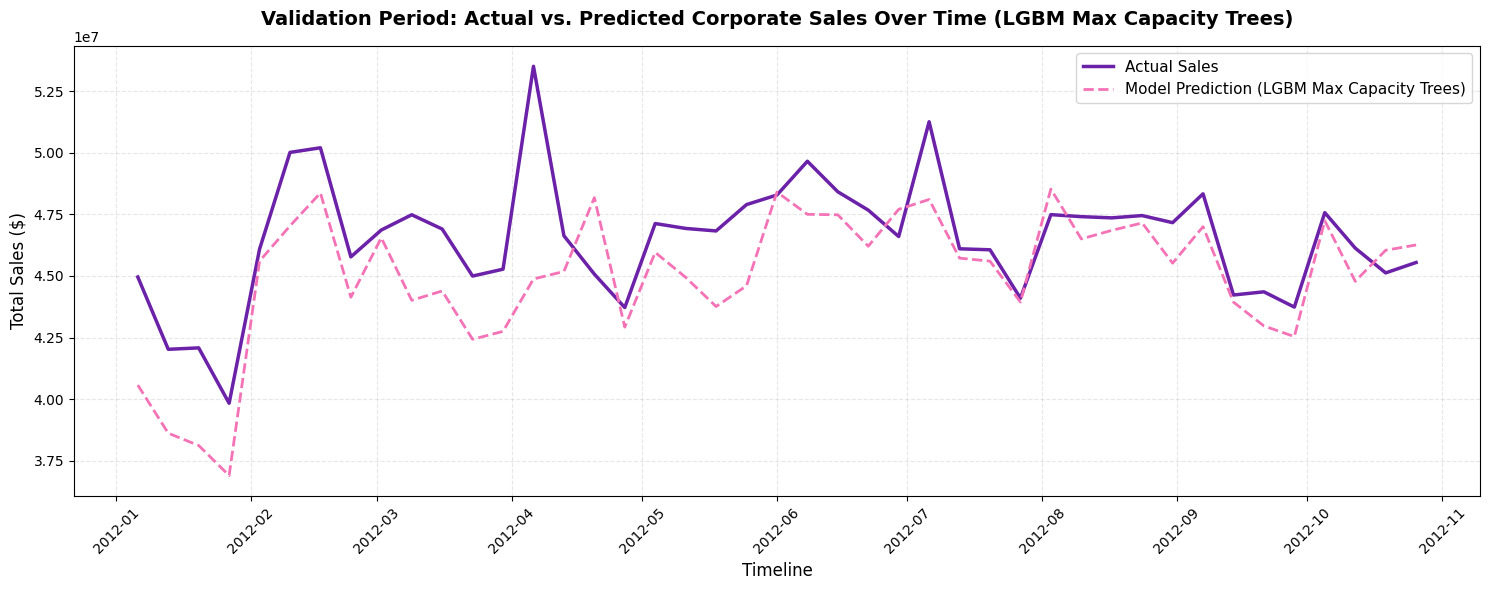

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

val_timeline = pd.DataFrame({
    'Date': pd.to_datetime(val_processed['Date']),
    'Actual': y_val,
    'Predicted': y_val_pred
})

val_timeline = val_timeline.groupby('Date').sum().reset_index()
val_timeline = val_timeline.sort_values('Date')

plt.figure(figsize=(15, 6))

plt.plot(
    val_timeline['Date'],
    val_timeline['Actual'],
    color='#6b21a8',
    linewidth=2.5,
    label='Actual Sales'
)

plt.plot(
    val_timeline['Date'],
    val_timeline['Predicted'],
    color='#f472b6',
    linewidth=2,
    linestyle='--',
    label='Model Prediction (LGBM Max Capacity Trees)'
)

plt.title('Validation Period: Actual vs. Predicted Corporate Sales Over Time (LGBM Max Capacity Trees)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [111]:
import mlflow

client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name("Walmart_LightGBM_Forecasting")

runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.mlflow.runName = 'LGBM_Max_Capacity_Trees_Final_F'",
    order_by=["start_time DESC"],
    max_results=1
)

run_id = runs[0].info.run_id
print("run_id:", run_id)

run_id: 4f9503eef44e4cc7bde3a5679bdeb624


In [113]:
import pickle

with open("walmart_lgbm_best_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print("🚀 Model loaded from local pickle:", loaded_model)

🚀 Model loaded from local pickle: LGBMRegressor(bagging_fraction=0.8, bagging_freq=1, feature_fraction=0.75,
              learning_rate=0.03, min_data_in_leaf=10, n_estimators=2000,
              n_jobs=-1, num_leaves=255, objective='mae', random_state=42,
              reg_alpha=10.0, reg_lambda=10.0, verbose=-1)


In [114]:
print(loaded_model.feature_name_)


['Store', 'Dept', 'IsHoliday_x', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'Month', 'Week', 'IsHoliday', 'sales_lag_52', 'Is_Pre_Holiday', 'Is_Post_Holiday']
